# Transformada de Fourier cuántica (QFT) e inversa


## Transformada discreta de Fourier y QFT

La transformada discreta de Fourier toma un vector complejo
$$
x=(x_0,\ldots,x_{N-1})
$$
y produce otro vector
$$
y_k=\frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}x_j e^{2\pi i jk/N}.
$$

La transformada cuántica de Fourier, o QFT, aplica esta misma transformación al vector de amplitudes de un estado cuántico. Es decir, si
$$
\ket{\psi}=\sum_{j=0}^{N-1}x_j\ket{j},
$$
entonces
$$
QFT_N\ket{\psi}=\sum_{k=0}^{N-1}y_k\ket{k}.
$$

Cuando $N=2^n$, la QFT puede implementarse eficientemente con compuertas de Hadamard, rotaciones de fase controladas y compuertas SWAP al final para corregir el orden de los qubits.



In [1]:
# !pip install qiskit

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [3]:
# Implementacion de la QFT
def qft(num_qubits: int, do_swaps: bool = True) -> QuantumCircuit:
    """
    Implementa la QFT sobre num_qubits qubits.
    """
    circuit = QuantumCircuit(num_qubits, name="QFT")

    for target in reversed(range(num_qubits)):
        circuit.h(target)

        for control in reversed(range(target)):
            k = target - control + 1
            angle = 2 * np.pi / (2 ** k)
            circuit.cp(angle, control, target)

    if do_swaps:
        for left in range(num_qubits // 2):
            right = num_qubits - left - 1
            circuit.swap(left, right)

    return circuit


# implementacion de la QFT inversa
def inverse_qft(num_qubits: int, do_swaps: bool = True) -> QuantumCircuit:
    """
    Implementa QFT^{-1} invirtiendo el circuito de la QFT.
    """
    circuit = QuantumCircuit(num_qubits, name="QFT†")

    if do_swaps:
        for left in range(num_qubits // 2):
            right = num_qubits - left - 1
            circuit.swap(left, right)

    for target in range(num_qubits):
        for control in range(target):
            k = target - control + 1
            angle = -2 * np.pi / (2 ** k)
            circuit.cp(angle, control, target)

        circuit.h(target)

    return circuit


# Preparador de los estados
def prepare_basis_state(circuit: QuantumCircuit, value: int, num_qubits: int) -> None:
    """
    Prepara el estado |value>.
    """
    if value < 0 or value >= 2 ** num_qubits:
        raise ValueError("value debe estar entre 0 y 2**num_qubits - 1.")

    bits = format(value, f"0{num_qubits}b")

    for qubit, bit in enumerate(reversed(bits)):
        if bit == "1":
            circuit.x(qubit)

### Ejemplo 

Prueba con $|6\rangle$ en 3 qubits

Circuito de la QFT


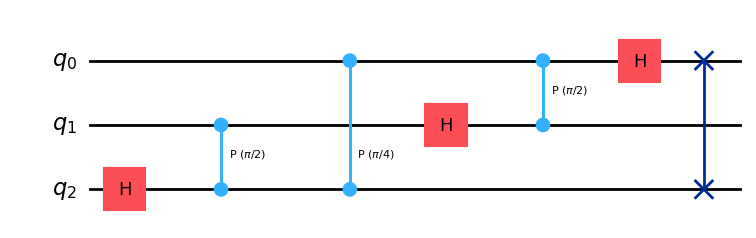

Circuito de la QFT^(-1)


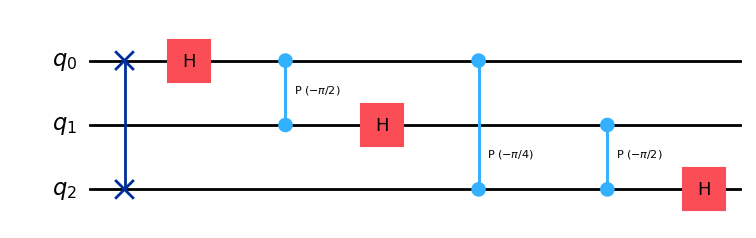

In [4]:
num_qubits = 3
value = 6
expected = format(value, f"0{num_qubits}b")

qft_circuit = qft(num_qubits)
iqft_circuit = inverse_qft(num_qubits)

print(f"Circuito de la QFT")
display(qft_circuit.draw("mpl", fold=-1))
print(f"Circuito de la QFT^(-1)")
display(iqft_circuit.draw("mpl", fold=-1))

Aplicar la QFT a $|6\rangle$

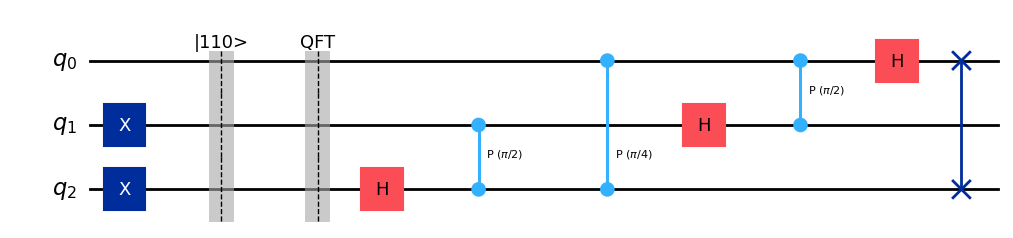

Amplitudes después de aplicar QFT a |110>:
|000>: +0.354+0.000j :  norma=0.354 
|001>: -0.000-0.354j :  norma=0.354 
|010>: -0.354+0.000j :  norma=0.354 
|011>: +0.000+0.354j :  norma=0.354 
|100>: +0.354+0.000j :  norma=0.354 
|101>: -0.000-0.354j :  norma=0.354 
|110>: -0.354+0.000j :  norma=0.354 
|111>: +0.000+0.354j :  norma=0.354 


In [8]:
qft_demo = QuantumCircuit(num_qubits)

prepare_basis_state(qft_demo, value, num_qubits)
qft_demo.barrier(label=f"|{expected}>")

qft_demo.barrier(label="QFT")
qft_demo.compose(qft_circuit, qubits=range(num_qubits), inplace=True)

state_after_qft = Statevector.from_instruction(qft_demo)

display(qft_demo.draw("mpl", fold=-1))

print(f"Amplitudes después de aplicar QFT a |{expected}>:")
for bitstring, amplitude in sorted(state_after_qft.to_dict().items()):
    print(f"|{bitstring}>: {amplitude.real:+.3f}{amplitude.imag:+.3f}j :  norma={abs(amplitude):.3f} ")

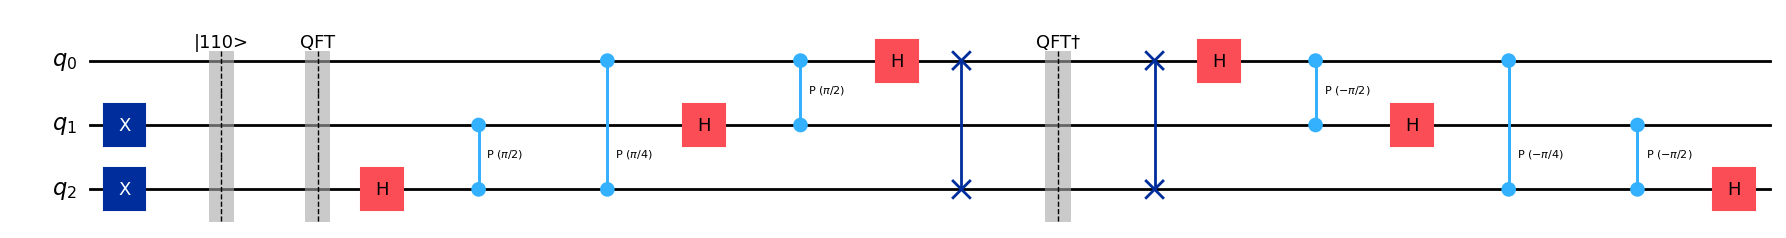


Muestras después de QFT seguida de QFT inversa:
{np.str_('110'): np.int64(1024)}


In [6]:
qft_inverse_demo = qft_demo.copy()
qft_inverse_demo.barrier(label="QFT†")
qft_inverse_demo.compose(iqft_circuit, qubits=range(num_qubits), inplace=True)

final_state = Statevector.from_instruction(qft_inverse_demo)
counts = final_state.sample_counts(shots=1024)

display(qft_inverse_demo.draw("mpl", fold=-1))

print("\nMuestras después de QFT seguida de QFT inversa:")
print(counts)

assert max(counts, key=counts.get) == expected

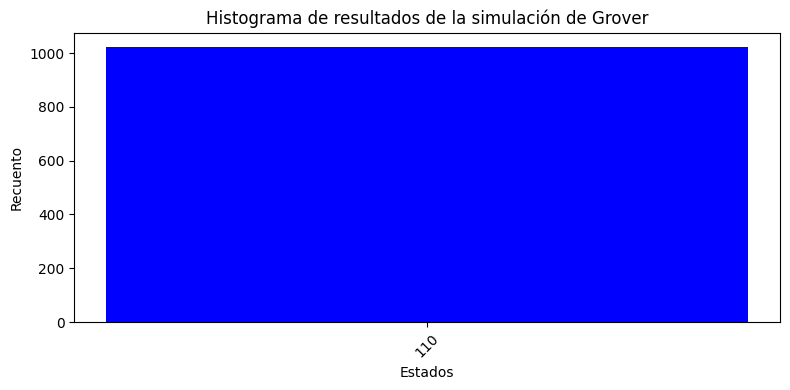

In [7]:
import matplotlib.pyplot as plt

bitstrings = list(counts.keys())
frecuencias = list(counts.values())

plt.figure(figsize=(8, 4))
plt.bar(bitstrings, frecuencias, color="blue")
plt.xlabel("Estados")
plt.ylabel("Recuento")
plt.title("Histograma de resultados de la simulación de Grover")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()